# Exploratory Data Analysis 

First look at the UCI dataset and understanding of data.

In [2]:
# some imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# loading data
dataset = "/Users/andrejartuschenko/Desktop/mailharpoon/backend/data/UCI_training_dataset.csv"
df = pd.read_csv(dataset)
df.columns = df.columns.str.lower() #lowercase the column names

In [4]:
# basic information
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_ip_address            11055 non-null  int64
 1   url_length                   11055 non-null  int64
 2   shortining_service           11055 non-null  int64
 3   having_at_symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   prefix_suffix                11055 non-null  int64
 6   having_sub_domain            11055 non-null  int64
 7   sslfinal_state               11055 non-null  int64
 8   domain_registeration_length  11055 non-null  int64
 9   favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  https_token                  11055 non-null  int64
 12  request_url                  11055 non-null  int64
 13  url_of_anchor                11055 non-null  int64
 14  l

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registeration_length,favicon,...,popupwidnow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [5]:
# data quality check
print(f'Data shape (rows, columns): {df.shape}')

print(f'Number of duplicate rows: {df.duplicated().sum()}')

print(f'Number of missing values: {df.isnull().sum().sum()}\n')

Data shape (rows, columns): (11055, 31)
Number of duplicate rows: 5206
Number of missing values: 0



Analysis confirmed the dataset has no missing values.

5,209 duplicates were identified. However, these are intentionally retained as they likely represent similar URL structures that could help our model recognize patterns in real phishing URLs. 

But I will compare two scenarios. First, I will generate a dataset without duplicates and train my models, and then I will do the same with duplicates.

/var/folders/_6/_jc6vxnd5f7dbg6lfksck48w0000gn/T/ipykernel_90697/1404748540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="result", palette='Blues')


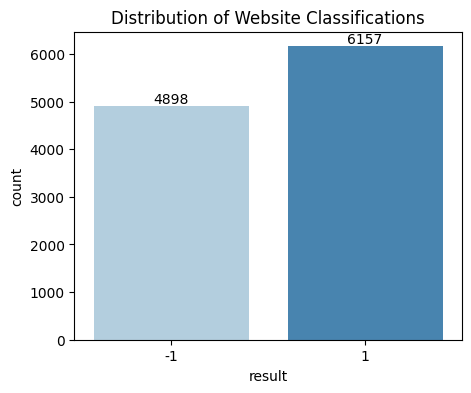

In [6]:
# check the distribution of the target variable "result"
plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="result", palette='Blues')

for container in ax.containers:
    ax.bar_label(container)
    
ax.set_title('Distribution of Website Classifications')
plt.show()

In [7]:
# check the distributions

df.apply(lambda x: x.value_counts().sort_index()).T


,-1,0,1
having_ip_address,3793.0,NaN,7262.0
url_length,8960.0,135.0,1960.0
shortining_service,1444.0,NaN,9611.0
having_at_symbol,1655.0,NaN,9400.0
double_slash_redirecting,1429.0,NaN,9626.0
prefix_suffix,9590.0,NaN,1465.0
having_sub_domain,3363.0,3622.0,4070.0
sslfinal_state,3557.0,1167.0,6331.0
domain_registeration_length,7389.0,NaN,3666.0
favicon,2053.0,NaN,9002.0


In [8]:
# NaNs as 0 and convert to integer
table = df.apply(lambda x: x.value_counts().sort_index()).T.fillna(0)
table = table.astype(int)
print(table)

                               -1     0      1
having_ip_address            3793     0   7262
url_length                   8960   135   1960
shortining_service           1444     0   9611
having_at_symbol             1655     0   9400
double_slash_redirecting     1429     0   9626
prefix_suffix                9590     0   1465
having_sub_domain            3363  3622   4070
sslfinal_state               3557  1167   6331
domain_registeration_length  7389     0   3666
favicon                      2053     0   9002
port                         1502     0   9553
https_token                  1796     0   9259
request_url                  4495     0   6560
url_of_anchor                3282  5337   2436
links_in_tags                3956  4449   2650
sfh                          8440   761   1854
submitting_to_email          2014     0   9041
abnormal_url                 1629     0   9426
redirect                        0  9776   1279
on_mouseover                 1315     0   9740
rightclick   

/var/folders/_6/_jc6vxnd5f7dbg6lfksck48w0000gn/T/ipykernel_90697/169327984.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="result", palette='Blues')


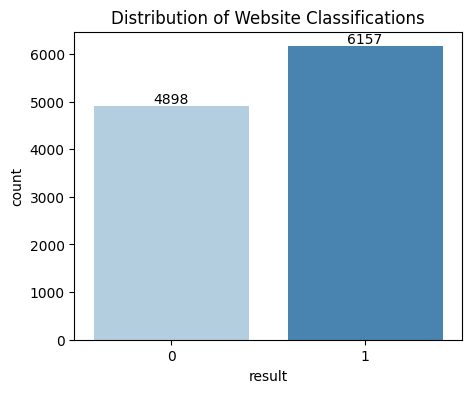

In [9]:
# replace the -1 values with 0 values (phishing URL)

df['result'] = df['result'].replace(-1, 0)

#check new distribution

plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="result", palette='Blues')

for container in ax.containers:
    ax.bar_label(container)
    
ax.set_title('Distribution of Website Classifications')
plt.show()

In [18]:
# class balance
df["result"].value_counts(normalize=True)

result
1    0.556943
0    0.443057
Name: proportion, dtype: float64

I kept the other feature columns in their original form [-1,0,1] tp preserve their semantic meaning and the models learning capacity.

## Analyse Feature vs. Target

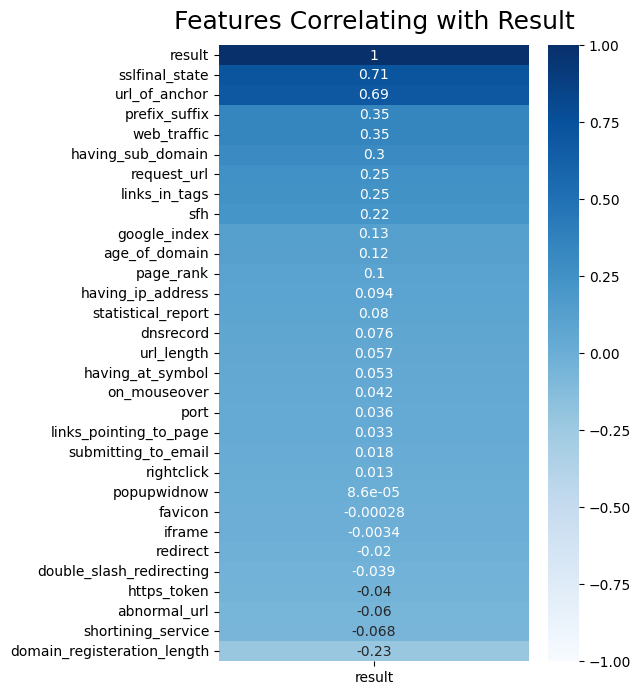

In [10]:
# check which features correlate most strongliy with the target (result)

plt.figure(figsize=(5, 8))
heatmap = sns.heatmap(df.corr()[['result']].sort_values(by='result', ascending=False), 
                      vmin=-1, vmax=1, annot=True, cmap='Blues')
heatmap.set_title('Features Correlating with Result', fontdict={'fontsize':18}, pad=12)
plt.show()



### Correlation Interpretation

Positive correlation values indicate that a feature is associated with legitimate websites.  
Negative correlation values indicate that a feature is more strongly associated with phishing websites.

### Strongest Legitimate Indicators

`sslfinal_state` (0.71) and `url_of_anchor` (0.69) show the strongest positive correlation with legitimate websites.  
These features contribute significantly to the classification task.

### Phishing Indicators

`domain_registration_length` (-0.23) shows the strongest negative correlation.  
Short domain registration periods are therefore more frequently associated with phishing websites.

### Weakly Correlated Features

Features with correlation values close to zero show only a weak linear relationship with the target variable.  
Their impact on linear models is likely limited.

### Methodological Note

Pearson correlation captures only linear relationships.  
Non-linear models (e.g., Random Forest, XGBoost) may still benefit from features with low linear correlation.


In [11]:
feature_means = df.groupby('result').mean().T
print(feature_means)

result                              0         1
having_ip_address            0.213557  0.393536
url_length                  -0.682523 -0.593958
shortining_service           0.790118  0.697905
having_at_symbol             0.658228  0.734286
double_slash_redirecting     0.770519  0.718369
prefix_suffix               -1.000000 -0.524119
having_sub_domain           -0.209473  0.281468
sslfinal_state              -0.479788  0.832223
domain_registeration_length -0.098408 -0.526393
favicon                      0.628828  0.628390
port                         0.700286  0.750528
https_token                  0.708044  0.648855
request_url                 -0.092283  0.408803
url_of_anchor               -0.632095  0.365438
links_in_tags               -0.330747  0.050999
sfh                         -0.784198 -0.445834
submitting_to_email          0.619845  0.648205
abnormal_url                 0.753369  0.667046
redirect                     0.122907  0.109956
on_mouseover                 0.731727  0

In [12]:
feature_means["diff"] = feature_means[1] - feature_means[0]
print(feature_means.sort_values("diff", ascending=False))

result                              0         1      diff
sslfinal_state              -0.479788  0.832223  1.312011
url_of_anchor               -0.632095  0.365438  0.997532
web_traffic                 -0.033891  0.542797  0.576688
request_url                 -0.092283  0.408803  0.501086
having_sub_domain           -0.209473  0.281468  0.490942
prefix_suffix               -1.000000 -0.524119  0.475881
links_in_tags               -0.330747  0.050999  0.381746
sfh                         -0.784198 -0.445834  0.338364
age_of_domain               -0.074724  0.169401  0.244125
page_rank                   -0.586362 -0.401981  0.184380
having_ip_address            0.213557  0.393536  0.179979
google_index                 0.621478  0.801202  0.179724
dnsrecord                    0.298489  0.439662  0.141173
statistical_report           0.657411  0.769043  0.111632
url_length                  -0.682523 -0.593958  0.088565
having_at_symbol             0.658228  0.734286  0.076058
on_mouseover  

In [19]:
df.var()

having_ip_address              0.901614
url_length                     0.586902
shortining_service             0.454274
having_at_symbol               0.509223
double_slash_redirecting       0.450256
prefix_suffix                  0.459873
having_sub_domain              0.668336
sslfinal_state                 0.831548
domain_registeration_length    0.886666
favicon                        0.604936
port                           0.469669
https_token                    0.544317
request_url                    0.965196
url_of_anchor                  0.511422
links_in_tags                  0.583654
sfh                            0.576298
submitting_to_email            0.596016
abnormal_url                   0.502609
redirect                       0.102318
on_mouseover                   0.419244
rightclick                     0.164829
popupwidnow                    0.623812
iframe                         0.332679
age_of_domain                  0.996340
dnsrecord                      0.857862


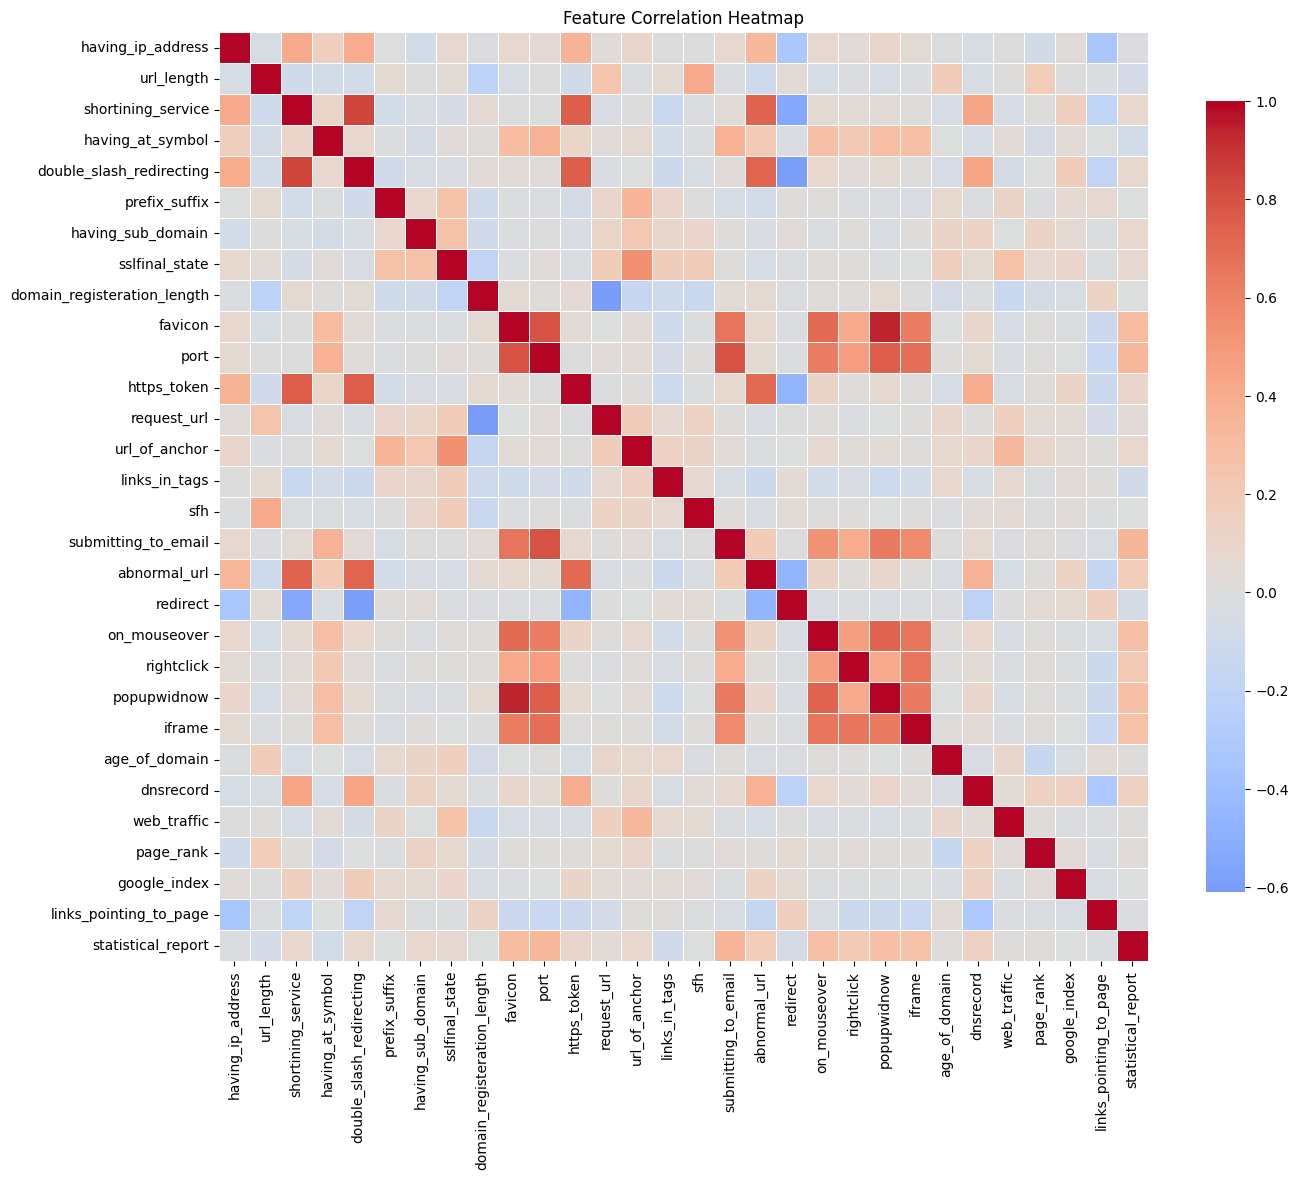

In [20]:
# Correlation matrix (Pearson)
corr_matrix = df.drop(columns=["result"]).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Duplicate Analysis

In [13]:
# total duplicates (exact row match including target)
total_duplicates = df.duplicated().sum()

# duplicates based only on feature space (excluding target)
feature_duplicates = df.drop(columns=["result"]).duplicated().sum()

total_duplicates, feature_duplicates

(np.int64(5206), np.int64(5270))

In [14]:
duplicate_groups = df[df.duplicated(keep=False)]
duplicate_groups.groupby(list(df.columns[:-1]))["result"].nunique().value_counts()

result
1    2579
2      29
Name: count, dtype: int64

In [15]:
# number of unique feature vectors
df.drop(columns=["result"]).drop_duplicates().shape

(5785, 30)

### Structural Pattern Analysis

The dataset contains 5,785 unique feature vectors out of ~11,000 total samples.

This indicates that nearly half of the dataset consists of repeated structural patterns.

Only 29 feature groups exhibit conflicting labels, 
which suggests a very low structural noise level.

In [16]:
# class balance
df["result"].value_counts(normalize=True)

result
1    0.556943
0    0.443057
Name: proportion, dtype: float64

## Project Structure

For technical reasons, implementing some features is more complex for a practical real-world web app. I will therefore train ML models with all features and ML models with URL-only features, which are currently easier to implement for my web app without having to access page-based (HTML) information or UI/JS behavior.


### Defininig URL-only Feature set


For deployment feasibility, a URL-only feature subset is defined.
This subset includes features that can be derived directly from the URL string
without fetching or executing webpage content.

The final feature selection will be applied in the preprocessing phase.

having_ip_address,
url_length,
shortining_service,
having_at_symbol,
double_slash_redirecting,
prefix_suffix,
having_sub_domain,
https_token
